# Project 2
ECE 232E Summer 2026 - Project 2: Social Network Mining 
Posted: Sunday, June 12, 2026  
Due: Sunday, July 26, 2026 at 11:59 PM PST

By Enoch Yeoh 906630606 / Nicolas Jeong Lee 605309755 / James Chen 005399315

## 1. Facebook Network

### 1. Structural Properties of the Facebook Network

#### 1.

In [28]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import random
import math

g = ig.Graph.Read_Edgelist("facebook_combined.txt", directed=False)

##### 1.1

In [2]:
print("Number of Nodes = ", g.vcount())
print("Number of Edges = ", g.ecount())

Number of Nodes =  4039
Number of Edges =  88234


##### 1.2

In [3]:
print("Connected = ", g.is_connected())

Connected =  True


#### 2

In [4]:
print("Diameter = ", g.diameter())

Diameter =  8


#### 3

Average Degree =  43.69101262688784
rough log-log slope: -1.1801644192508813


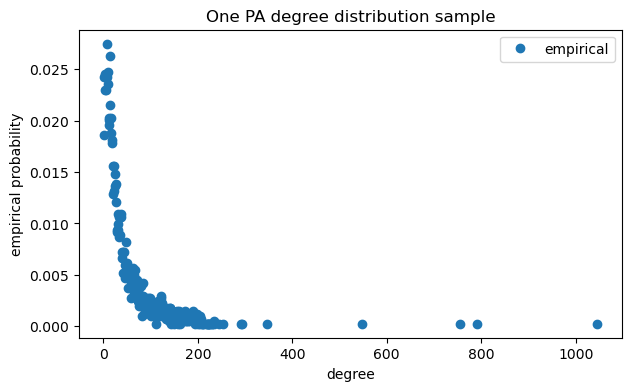

In [5]:
deg = np.asarray(g.degree())
print("Average Degree = ", sum(deg)/g.vcount())
k, counts = np.unique(deg, return_counts=True)
prob = counts / counts.sum()

mask = (k >= 1 ) & (counts > 0)
slope, intercept = np.polyfit(np.log(k[mask]), np.log(prob[mask]), 1)
print("rough log-log slope:", slope)

plt.figure(figsize=(7, 4))
plt.plot(k, prob, "o", label="empirical")
plt.legend()
plt.xlabel("degree")
plt.ylabel("empirical probability")
plt.title("One PA degree distribution sample")
plt.show()

#### 4

rough log-log slope: -1.1801644192508813


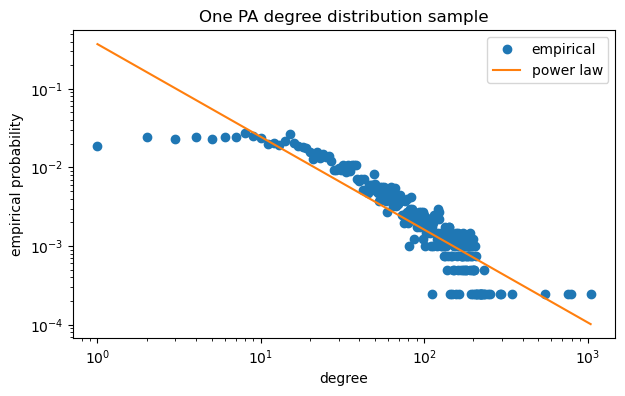

In [6]:
deg = np.asarray(g.degree())
k, counts = np.unique(deg, return_counts=True)
prob = counts / counts.sum()

mask = (k >= 1 ) & (counts > 0)
slope, intercept = np.polyfit(np.log(k[mask]), np.log(prob[mask]), 1)
print("rough log-log slope:", slope)

plt.figure(figsize=(7, 4))
plt.loglog(k, prob, "o", label="empirical")
plt.loglog(k, np.exp(intercept) * k**slope, label="power law")
plt.legend()
plt.xlabel("degree")
plt.ylabel("empirical probability")
plt.title("One PA degree distribution sample")
plt.show()

### 2. Personalized Network

#### 5

In [7]:
nodes = [0] + g.neighbors(0)
pn = g.induced_subgraph(nodes)
print("Number of Nodes = ", pn.vcount())
print("Number of Edges = ", pn.ecount())

Number of Nodes =  348
Number of Edges =  2866


#### 6

In [8]:
print("Diameter = ", pn.diameter())

Diameter =  2


Provide upper and lower bound of the diameter

#### 7

Write the answer

### 3. Core node's personalized network

#### 8

In [9]:
count = 0
core_node = []
for node in range(0, g.vcount()):
    if len(g.neighbors(node)) > 200:  
        core_node.append(node)
        count += 1
print("Core Nodes = ", core_node)
print("Num of Core Nodes = ", count)

total_degree = 0
for node in core_node:
    total_degree += g.degree(node)
print("Average Degree of Core Nodes = ", total_degree / len(core_node))

Core Nodes =  [0, 107, 348, 483, 1086, 1199, 1352, 1431, 1584, 1589, 1663, 1684, 1730, 1746, 1768, 1800, 1827, 1888, 1912, 1941, 1985, 1993, 2047, 2078, 2123, 2142, 2206, 2218, 2229, 2233, 2240, 2266, 2347, 2410, 2464, 2507, 2543, 2560, 2611, 3437]
Num of Core Nodes =  40
Average Degree of Core Nodes =  279.375


### 3.1 Core node's personalized network

#### 9

In [10]:
def get_communities(g):
    results = {}

    # Fast-Greedy
    fg = g.community_fastgreedy()
    results["Fast-Greedy"] = fg.as_clustering()

    # Edge-Betweenness
    eb = g.community_edge_betweenness()
    results["Edge-Betweenness"] = eb.as_clustering()

    # Infomap
    results["Infomap"] = g.community_infomap()

    return results

def draw_network(pn, clustering, layout, ax, title):
    pal = ig.RainbowPalette(n=max(len(clustering), 2))
    ig.plot(
        clustering,
        target=ax,
        layout=layout,
        palette=pal,
        vertex_size=10,
        vertex_frame_width=0.3,
        edge_color="lightgray",
        edge_width=0.4,
    )
    ax.set_title(title)
    ax.set_axis_off()

def plot_node(node_id):
    pn = g.induced_subgraph([node_id] + g.neighbors(node_id))
    layout = pn.layout("fr")
    results = get_communities(pn)

    print(f"Core Node ID {node_id + 1}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (name, cl) in zip(axes, results.items()):
        print(f"  {name}: {len(cl)} communities, mod = {cl.modularity:.4f}")
        draw_network(pn, cl, layout, ax, f"{name}\nmod = {cl.modularity:.3f}")
    fig.suptitle(f"Core Node ID {node_id + 1}", fontsize=14)
    plt.tight_layout()
    plt.show()

Core Node ID 1  (|V|=348, |E|=2866)
  Fast-Greedy: 8 communities, mod = 0.4131
  Edge-Betweenness: 41 communities, mod = 0.3533
  Infomap: 24 communities, mod = 0.3909


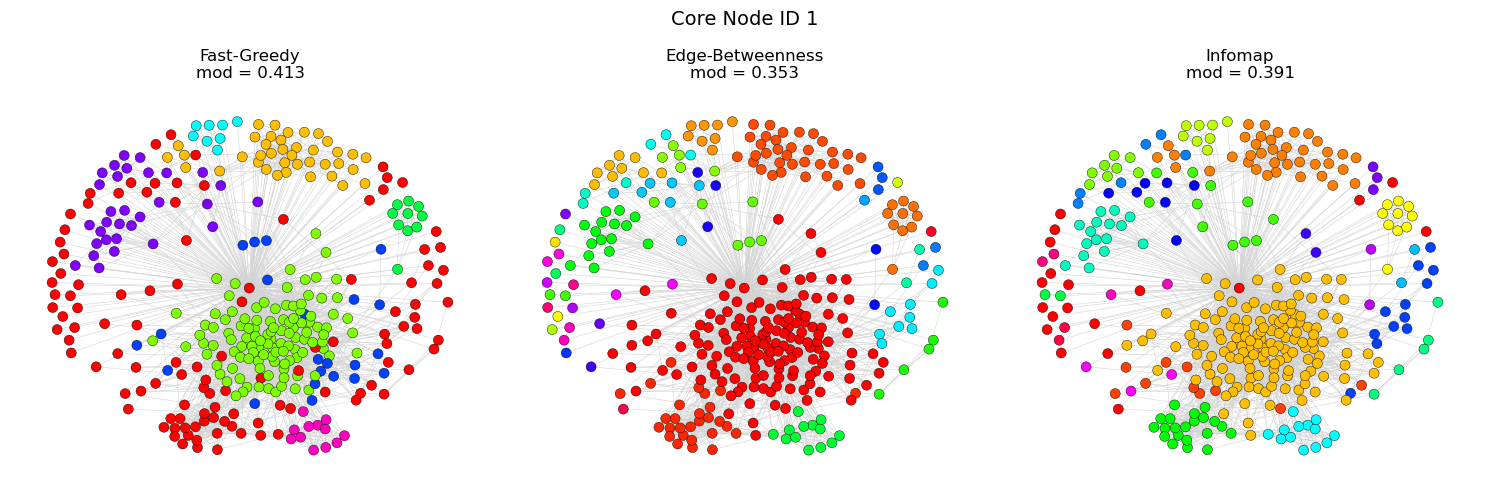

In [11]:
plot_node(0)

Core Node ID 108  (|V|=1046, |E|=27795)
  Fast-Greedy: 9 communities, mod = 0.4359
  Edge-Betweenness: 52 communities, mod = 0.5068
  Infomap: 22 communities, mod = 0.5085


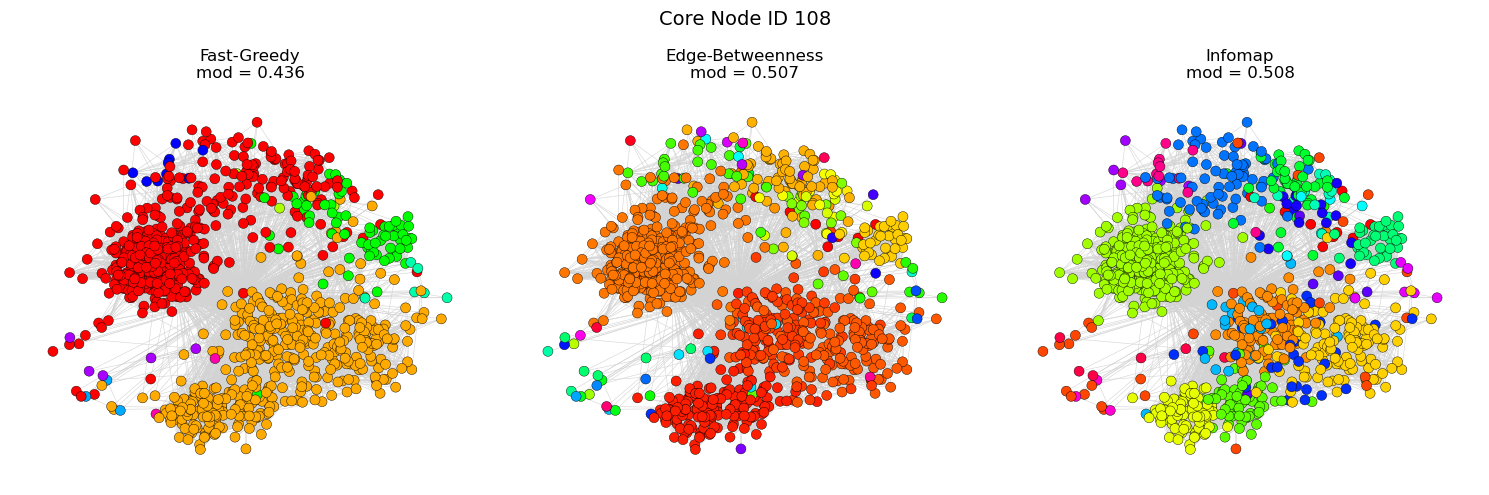

In [12]:
plot_node(107)

Core Node ID 349  (|V|=230, |E|=3441)
  Fast-Greedy: 5 communities, mod = 0.2517
  Edge-Betweenness: 104 communities, mod = 0.1335
  Infomap: 8 communities, mod = 0.2175


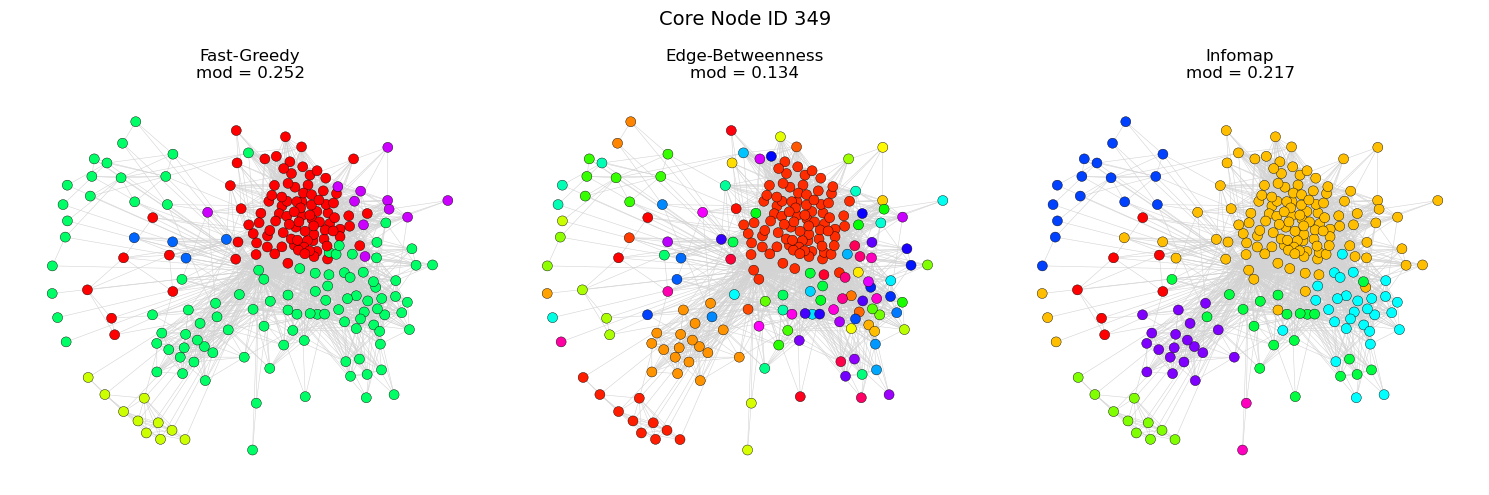

In [13]:
plot_node(348)

Core Node ID 484  (|V|=232, |E|=4525)
  Fast-Greedy: 3 communities, mod = 0.5070
  Edge-Betweenness: 10 communities, mod = 0.4891
  Infomap: 4 communities, mod = 0.5153


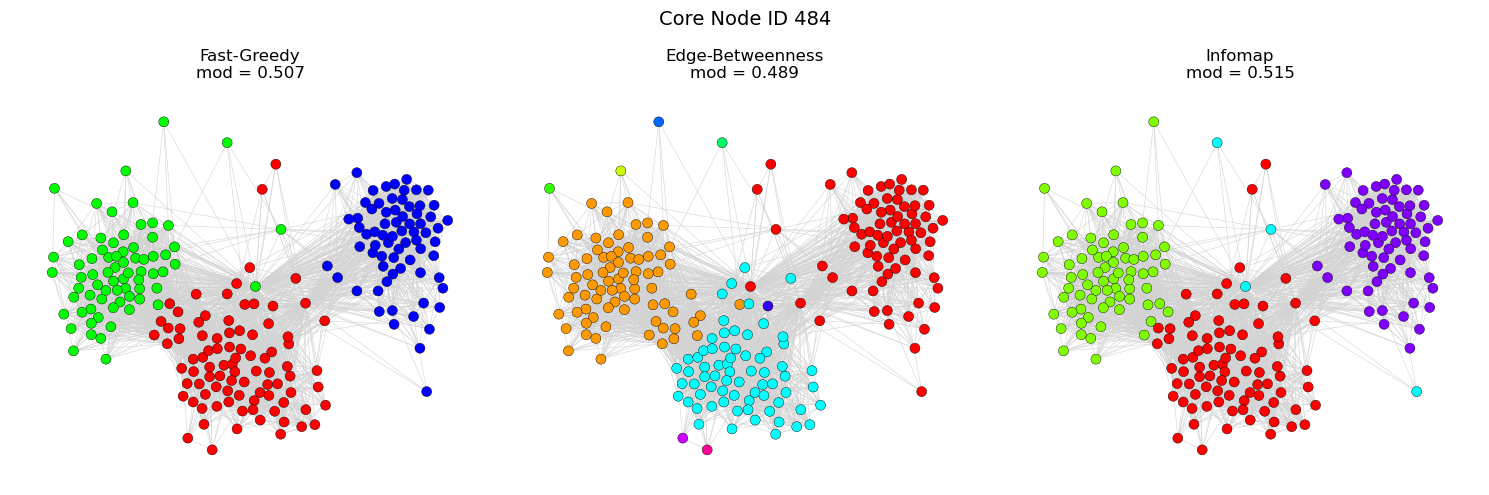

In [14]:
plot_node(483)

Core Node ID 1087  (|V|=206, |E|=7409)
  Fast-Greedy: 2 communities, mod = 0.1455
  Edge-Betweenness: 9 communities, mod = 0.0276
  Infomap: 4 communities, mod = 0.0269


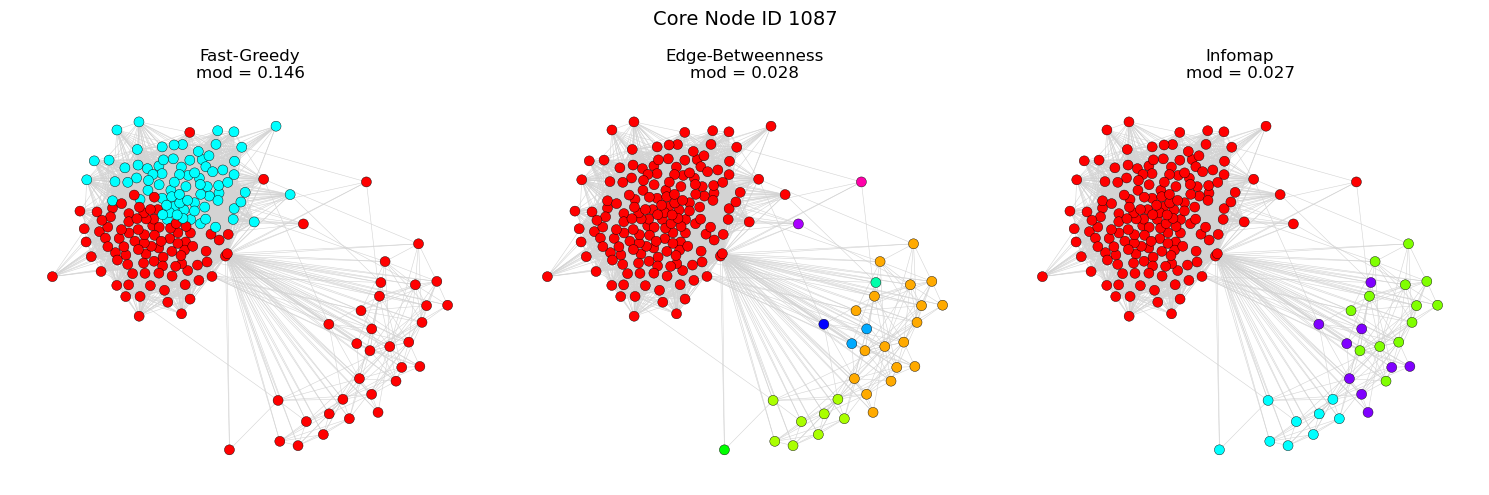

In [15]:
plot_node(1086)

### 3.2 Community Structure with the core node removed

#### 10

In [16]:
def plot_node_v2(node_id):
    pn = g.induced_subgraph([node_id] + g.neighbors(node_id))
    pn.delete_vertices(0)
    layout = pn.layout("fr").coords
    
    results = get_communities(pn)

    print(f"Core Node ID {node_id + 1} Deleted")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (name, cl) in zip(axes, results.items()):
        print(f"  {name}: {len(cl)} communities, mod = {cl.modularity:.4f}")
        draw_network(pn, cl, layout, ax, f"{name}\nmod = {cl.modularity:.3f}")
    fig.suptitle(f"Core Node ID {node_id + 1} Deleted Modified Personalized Network", fontsize=14)
    plt.tight_layout()
    plt.show()

Core Node ID 1 Deleted
  Fast-Greedy: 26 communities, mod = 0.4419
  Edge-Betweenness: 50 communities, mod = 0.4161
  Infomap: 36 communities, mod = 0.4198


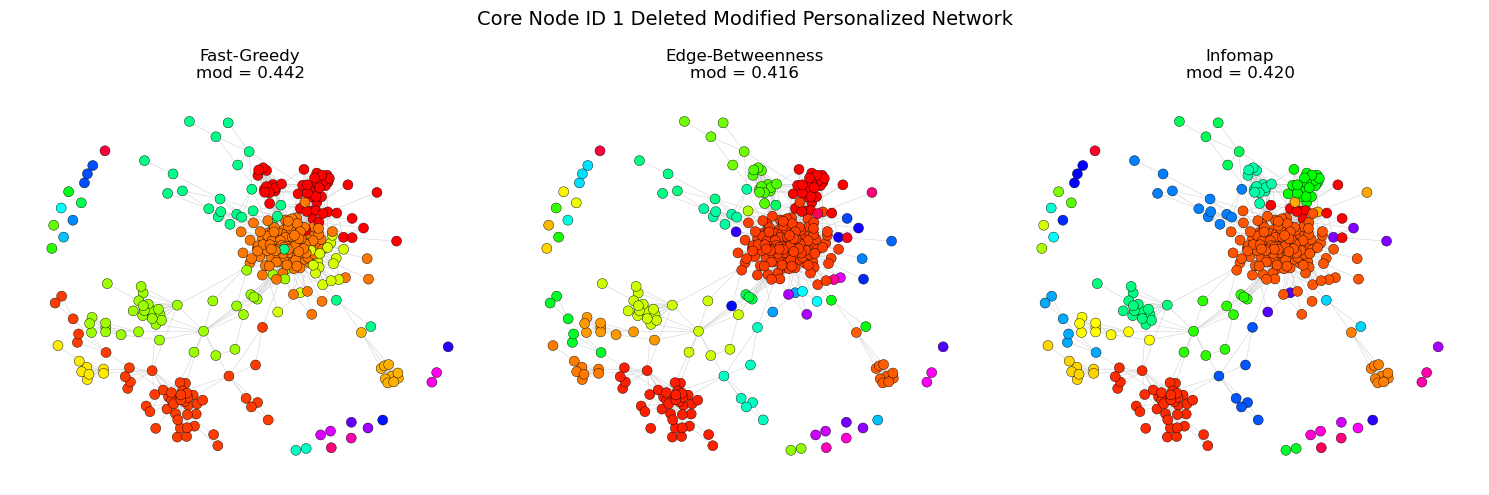

In [17]:
plot_node_v2(0)

Core Node ID 108 Deleted
  Fast-Greedy: 9 communities, mod = 0.4360
  Edge-Betweenness: 52 communities, mod = 0.5056
  Infomap: 23 communities, mod = 0.5093


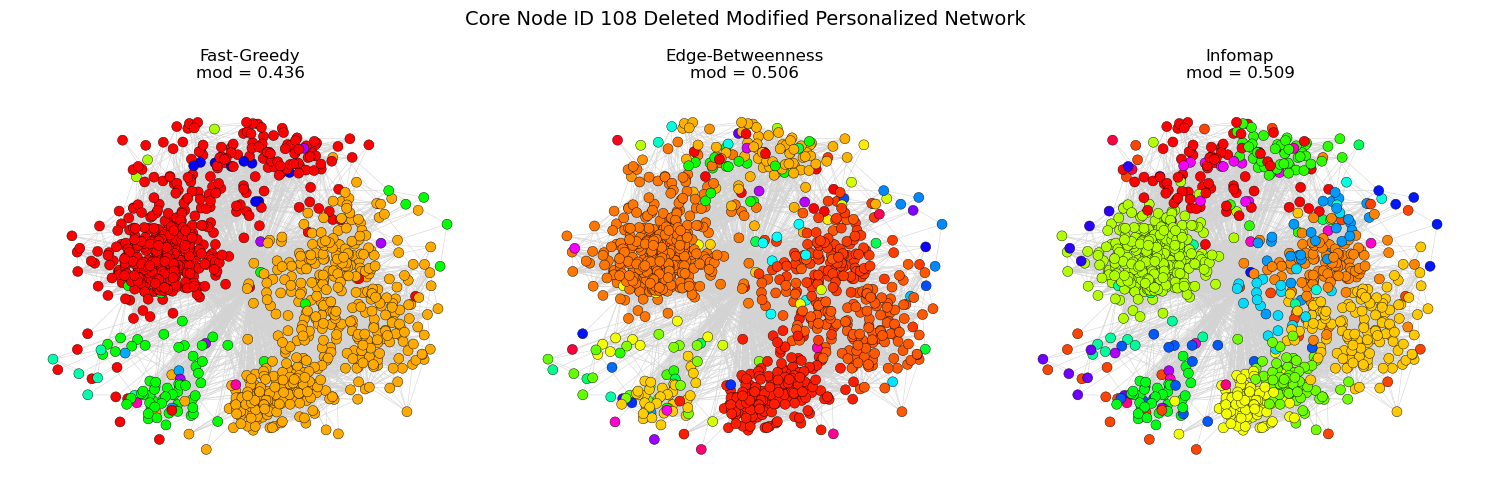

In [18]:
plot_node_v2(107)

Core Node ID 349 Deleted
  Fast-Greedy: 5 communities, mod = 0.2502
  Edge-Betweenness: 103 communities, mod = 0.1337
  Infomap: 9 communities, mod = 0.2167


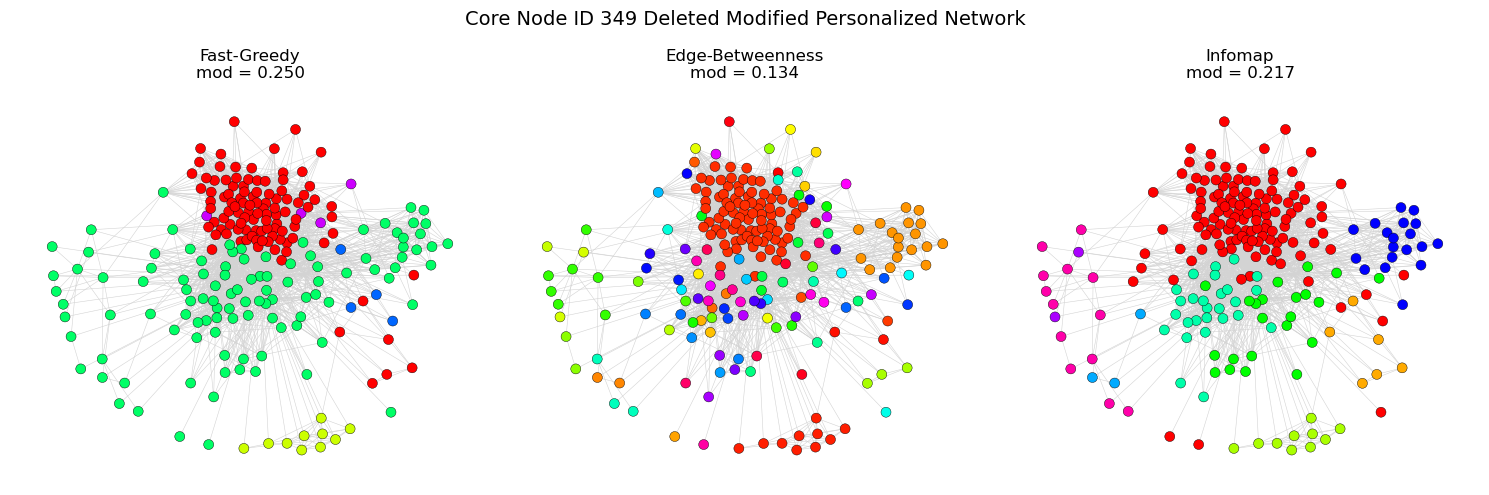

In [19]:
plot_node_v2(348)

Core Node ID 484 Deleted
  Fast-Greedy: 3 communities, mod = 0.5211
  Edge-Betweenness: 13 communities, mod = 0.4956
  Infomap: 4 communities, mod = 0.5291


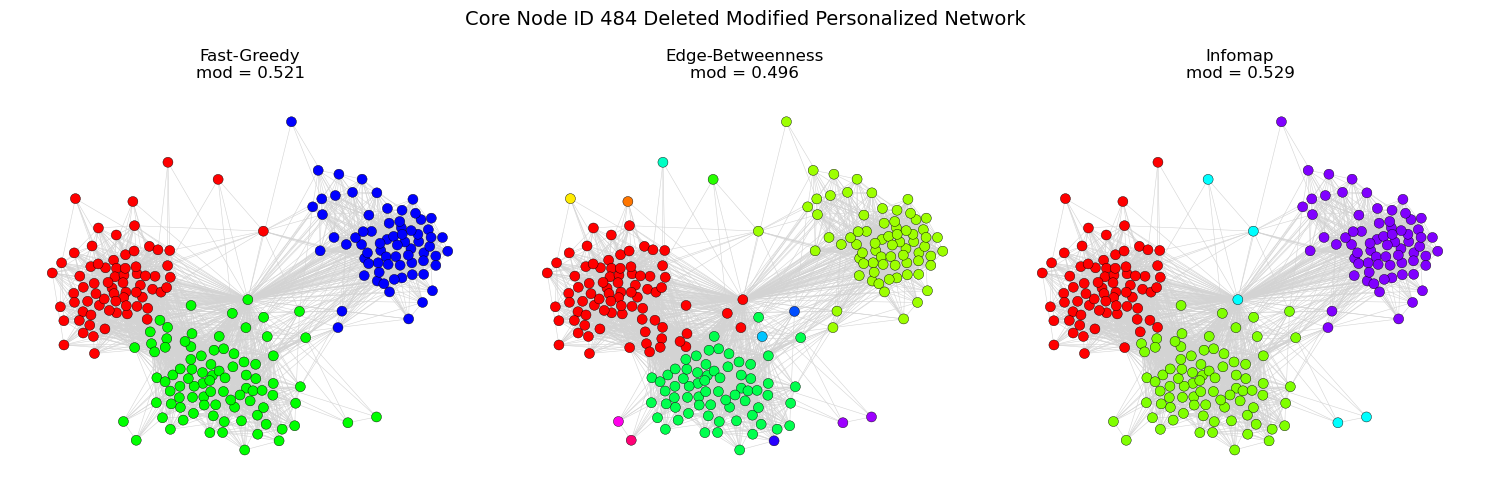

In [20]:
plot_node_v2(483)

Core Node ID 1088 Deleted
  Fast-Greedy: 2 communities, mod = 0.0799
  Edge-Betweenness: 1 communities, mod = 0.0000
  Infomap: 1 communities, mod = 0.0000


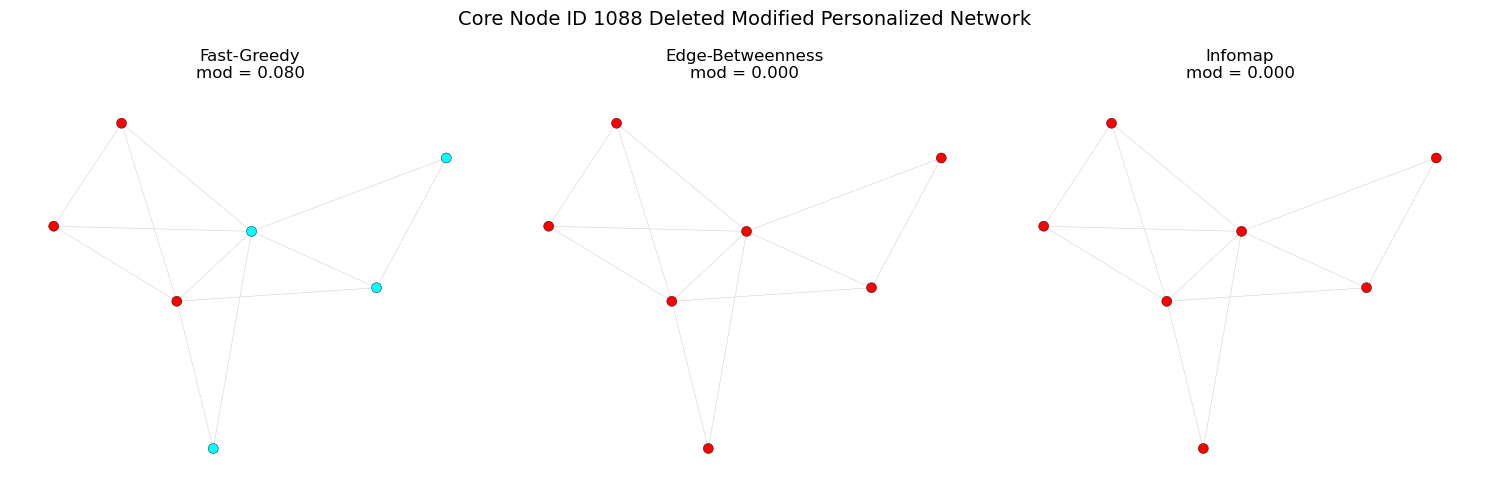

In [21]:
plot_node_v2(1087)

Compare Modularity

### 3.3 Characteristic of nodes in the personalized network

#### 11

Embeddedness of a node is defined as the number of mutual friends a node shares with the core node.
Since a core node's personalized network is made up of the core node and all of the core node's neighbors, all of the neighbors of non-core node are also neighbors of core node(thus those are the mutual friends). In other words, the degree of a non-core nodes can tell us about the embededness between the core node and non-core node.

More specifically, for a non-core node $v$ in core node's personalized network $PN$, we can define embededness between the core node and non-core node as:

$$Embededness(v) = deg(v) - 1 $$
We subtract one since we exclude the edge connecting $v$ and the core node(only interested in mutual friends).

#### 12

In [22]:
# Functions + Definitions
def embeddedness(pn, v, core=0):
    return pn.degree(v) - 1

def dispersion(pn, v, core=0):
    C = list(set(pn.neighbors(core)) & set(pn.neighbors(v)))
    if len(C) < 2: #If only one mutual or no mutuals then 
        return 0
    C_removed = [x for x in range(pn.vcount()) if x not in (core, v)] #Remove v and core node
    C_removed_pn = pn.induced_subgraph(C_removed) #Create modified network without v and core node

    #Remap the indices
    remap_idx = {old: new for new, old in enumerate(C_removed)}
    mutual_idx = [remap_idx[m] for m in C]

    #Get all mutual friends distances
    dist_mat = np.array(C_removed_pn.distances(source=mutual_idx, target=mutual_idx), dtype = float)
    dist_mat[np.isinf(dist_mat)] = 0 # Remove any nodes with no path between them
    return dist_mat.sum() / 2  #dist_mat is symmetric so can sum the matrix and divide by 2(to avoid double count)

def q12_histogram(core):
    pn = g.induced_subgraph([core] + g.neighbors(core))
    others = [v for v in range(pn.vcount()) if v != 0]
    emb = [embeddedness(pn, v) for v in others]
    disp = [dispersion(pn, v) for v in others]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(emb, bins=30, color="steelblue", edgecolor="black")
    axes[0].set_title("Embeddedness"); axes[0].set_xlabel("embeddedness")
    axes[0].set_ylabel("count")
    axes[1].hist(disp, bins=30, color="indianred", edgecolor="black")
    axes[1].set_title("Dispersion"); axes[1].set_xlabel("dispersion")
    fig.suptitle(f"Core Node ID {core + 1}", fontsize=14)
    plt.tight_layout(); plt.show()

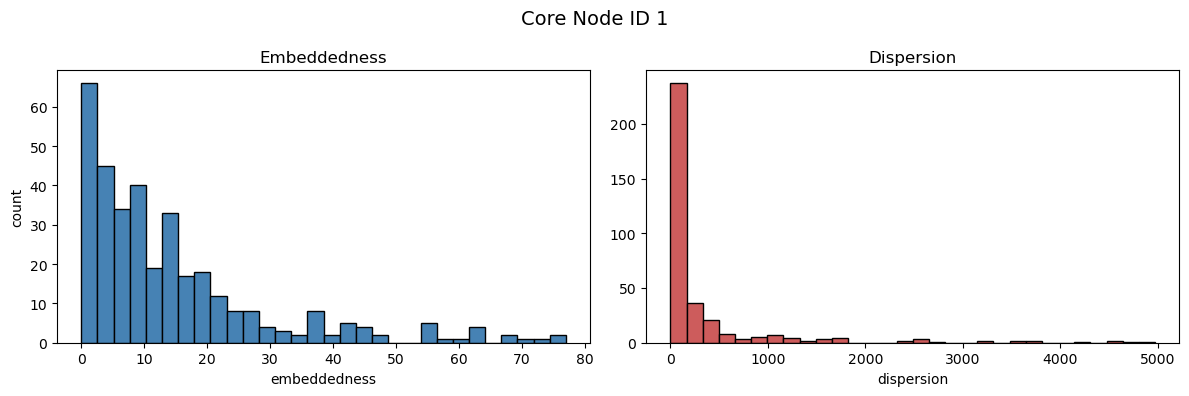

In [23]:
q12_histogram(0)

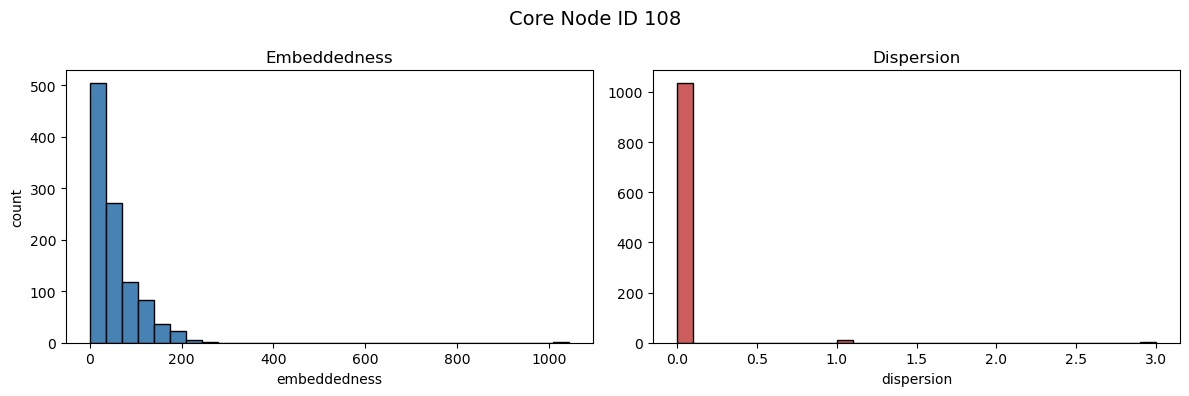

In [24]:
q12_histogram(107)

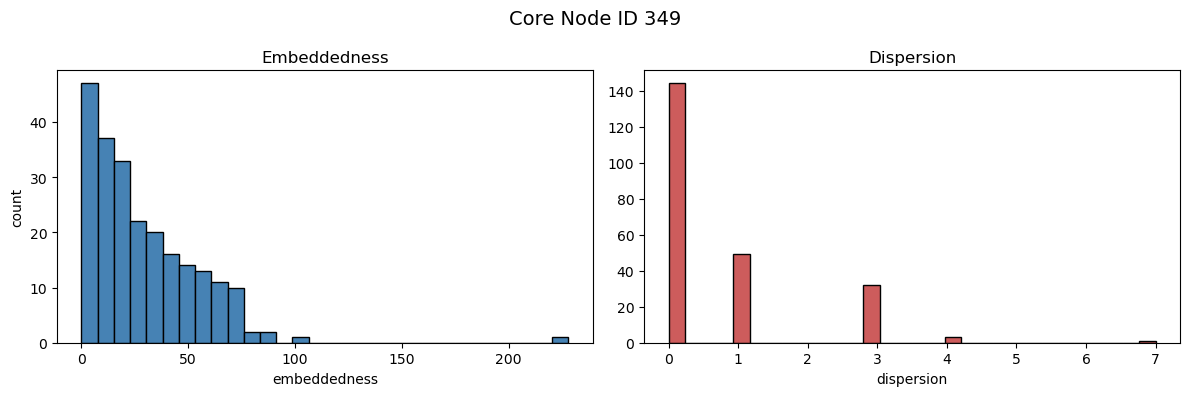

In [25]:
q12_histogram(348)

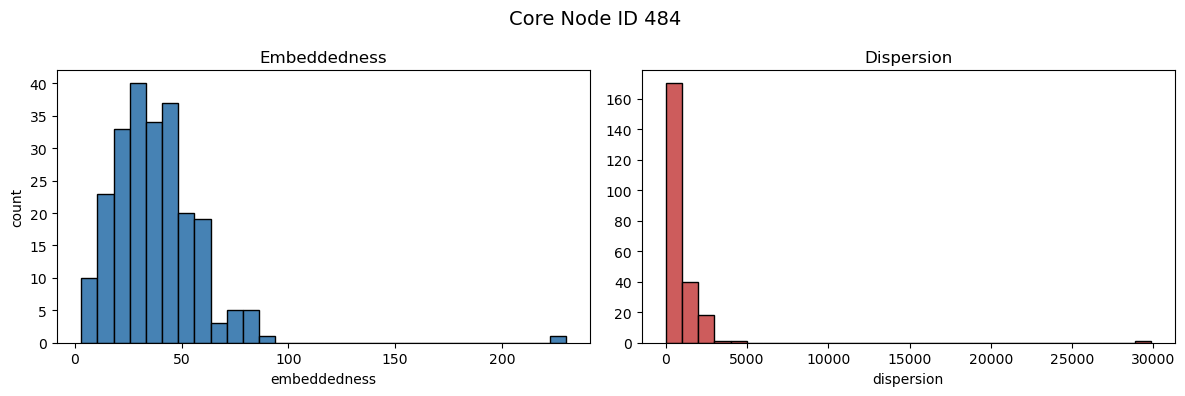

In [26]:
q12_histogram(483)

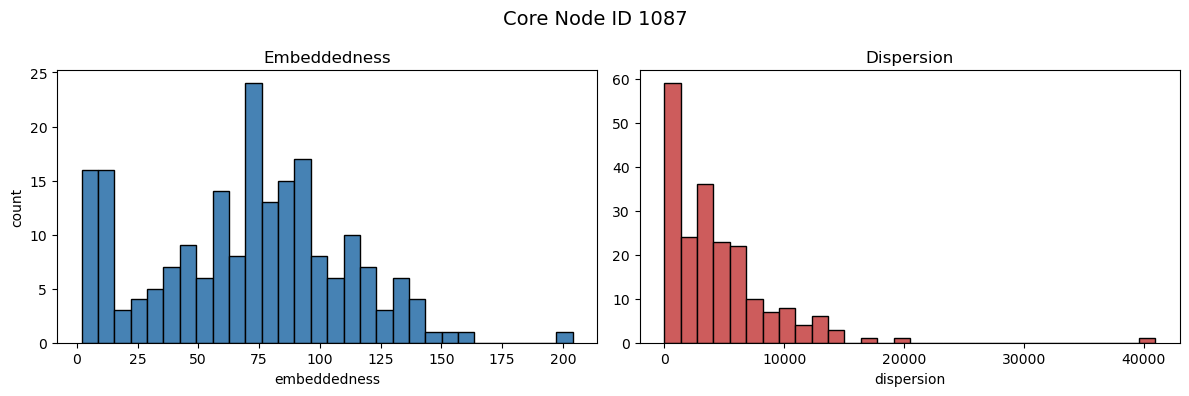

In [27]:
q12_histogram(1086)

#### 13

In [ ]:
def highlight_draw_network(pn, clustering, layout, ax, title, highlights):
    k = max(len(clustering), 1)
    cmap = plt.get_cmap("tab20", k)

    # per-vertex styling
    vcolors = [cmap(m) for m in clustering.membership]
    vsizes  = [10] * pn.vcount()
    vshapes = ["circle"] * pn.vcount()
    for v, col in highlights.items():
        vcolors[v] = col
        vsizes[v]  = 32
        vshapes[v] = "diamond"

    # per-edge styling: incident edges take the highlight color
    ecolors, ewidths = [], []
    for e in pn.es:
        col = highlights.get(e.source) or highlights.get(e.target)
        ecolors.append(col if col else "lightgray")
        ewidths.append(1.6 if col else 0.3)

    ig.plot(
        pn,                         
        target=ax,
        layout=layout,
        vertex_color=vcolors,
        vertex_size=vsizes,
        vertex_shape=vshapes,
        vertex_frame_width=0.3,
        edge_color=ecolors,
        edge_width=ewidths,
    )
    ax.set_title(title)
    ax.set_axis_off()

def q13_plot(core):
    pn, orig = build_pn(core)
    layout = pn.layout("fr")
    fg = pn.community_fastgreedy().as_clustering()

    others = [v for v in range(pn.vcount()) if v != 0]
    disp = {v: dispersion(pn, v) for v in others}
    max_disp = max(disp, key=disp.get)
    print(f"Core Node {core + 1}: max-dispersion node = graph ID "
          f"{orig[max_disp] + 1} (dispersion = {disp[max_disp]:.1f})")

    fig, ax = plt.subplots(figsize=(7, 7))
    highlight_draw_network(pn, fg, layout, ax,
                   f"Core Node {core + 1} — max dispersion highlighted",
                   {max_disp: "red"})
    plt.tight_layout(); plt.show()

In [ ]:
q13_plot(0)

In [ ]:
q13_plot(107)

In [ ]:
q13_plot(348)

In [ ]:
q13_plot(483)

In [ ]:
q13_plot(1086)

#### 14

In [ ]:
def q14_plot(core):
    pn, orig = build_pn(core)
    layout = pn.layout("fr")
    fg = pn.community_fastgreedy().as_clustering()

    others = [v for v in range(pn.vcount()) if v != 0]
    emb  = {v: embeddedness(pn, v) for v in others}
    disp = {v: dispersion(pn, v) for v in others}

    nz = [v for v in others if emb[v] > 0]        # exclude zero embeddedness
    max_emb   = max(nz, key=lambda v: emb[v])
    max_ratio = max(nz, key=lambda v: disp[v] / emb[v])

    print(f"Core Node {core + 1}:")
    print(f"  max embeddedness       -> graph ID {orig[max_emb] + 1} "
          f"(emb = {emb[max_emb]})")
    print(f"  max disp/embeddedness  -> graph ID {orig[max_ratio] + 1} "
          f"(ratio = {disp[max_ratio]/emb[max_ratio]:.2f})")

    fig, ax = plt.subplots(figsize=(7, 7))
    highlight_draw(pn, fg, layout, ax,
                   f"Core Node {core + 1} — max embeddedness (blue) "
                   f"& max disp/emb (red)",
                   {max_emb: "blue", max_ratio: "red"})
    plt.tight_layout(); plt.show()

In [ ]:
q14_plot(0)

In [ ]:
q14_plot(107)

In [ ]:
q14_plot(348)

In [ ]:
q14_plot(483)

In [ ]:
q14_plot(1086)

#### 15

Type Answer Here

### 4. Friend Recommendation in Personalized Networks

In [ ]:
pn_415 = g.induced_subgraph([414] + g.neighbors(414))

#### 16

In [ ]:
nodes_degree_24 = pn_415.vs.select(_degree=24)
print("|N_r| = ",len(nodes_degree_24))

#### 17

In [ ]:
def score_matrix(gm, measure):
    """Full n x n similarity matrix for the given measure."""
    if measure == "common":
        A = np.array(gm.get_adjacency().data)
        return A @ A                       # (A^2)[i][j] = # common neighbors
    if measure == "jaccard":
        return np.array(gm.similarity_jaccard())
    if measure == "adamic":
        return np.array(gm.similarity_inverse_log_weighted())
    raise ValueError(measure)

def avg_accuracy(pn, Nr, measure, trials=10, p=0.25, seed=0):
    rng = random.Random(seed)
    user_accs = []
    for i in Nr:
        accs = []
        for _ in range(trials):
            gm = pn.copy()

            # 1. delete each edge of i with prob 0.25 -> R_i
            to_del = [eid for eid in gm.incident(i) if rng.random() < p]
            if not to_del:
                continue                    # |R_i| = 0, accuracy undefined
            Ri = set()
            for eid in to_del:
                e = gm.es[eid]
                Ri.add(e.target if e.source == i else e.source)
            gm.delete_edges(to_del)

            # 2. recommend |R_i| non-neighbors with highest score
            S = score_matrix(gm, measure)[i]
            nb = set(gm.neighbors(i))
            cands = [j for j in range(gm.vcount()) if j != i and j not in nb]
            cands.sort(key=lambda j: S[j], reverse=True)
            Pi = set(cands[:len(Ri)])

            # 3. accuracy
            accs.append(len(Pi & Ri) / len(Ri))
        if accs:
            user_accs.append(sum(accs) / len(accs))
    return sum(user_accs) / len(user_accs)

for m, label in [("common", "Common Neighbors"),
                 ("jaccard", "Jaccard"),
                 ("adamic",  "Adamic-Adar")]:
    print(f"{label:18s}: {avg_accuracy(pn, Nr, m):.4f}")

## 2. Google+ Network